# Online Payment Fraud Detection using Machine Learning
## Objective

The objective of this project is to develop a machine learning model capable of detecting fraudulent online payment transactions using the PaySim dataset. The project includes exploratory data analysis, statistical hypothesis testing, predictive modeling, hyperparameter tuning, and deployment using Streamlit.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Dataset
The PaySim dataset is a synthetic dataset that simulates mobile money transactions
based on financial transaction patterns. It contains over 6 million transactions and 
includes both legitimate and fraudulent activities.

Target Variable:
- isFraud

Predictor Variables:
- Transaction amount
- Transaction type
- Account balances
- Transaction time

In [2]:
df=pd.read_csv("credit_card.csv")

In [3]:
df.head(10)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.0,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.0,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.0,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.0,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.0,0.00,0,0
5,1,PAYMENT,7817.71,C90045638,53860.00,46042.29,M573487274,0.0,0.00,0,0
6,1,PAYMENT,7107.77,C154988899,183195.00,176087.23,M408069119,0.0,0.00,0,0
7,1,PAYMENT,7861.64,C1912850431,176087.23,168225.59,M633326333,0.0,0.00,0,0
8,1,PAYMENT,4024.36,C1265012928,2671.00,0.00,M1176932104,0.0,0.00,0,0
9,1,DEBIT,5337.77,C712410124,41720.00,36382.23,C195600860,41898.0,40348.79,0,0


## Data Inspection

The first step is to understand the structure of the dataset.We examine the number of observations, variable types, missing values, duplicate records, and summary statistics.

In [4]:
df.shape

(6362620, 11)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [6]:
desc_stats = df.describe().T
desc_stats["skewness"] = df.skew(numeric_only=True)
desc_stats["kurtosis"] = df.kurtosis(numeric_only=True)
desc_stats

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02,0.375177,0.329071
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07,30.993949,1797.956705
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07,5.249136,32.964879
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07,5.176884,32.066985
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08,19.921758,948.674125
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08,19.352302,862.156508
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00,27.779538,769.702982
isFlaggedFraud,6362620.0,2.514687e-06,1.585775e-03,0.0,0.00,0.000,0.000000e+00,1.000000e+00,630.603629,397659.062500


In [7]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

## Feature Engineering

The original dataset contains a variable called **step**, representing the number of hours elapsed from the start of the simulation.
To improve interpretability, this variable was transformed into:
- Day
- Hour
These features make temporal transaction patterns easier to analyze.

In [9]:
df['day'] = (df['step'] - 1) // 24 + 1
df['hour'] = (df['step'] - 1) % 24+1

In [10]:
df["isFraud"].value_counts()/df.shape[0]*100

isFraud
0    99.870918
1     0.129082
Name: count, dtype: float64

In [11]:
df["isFlaggedFraud"].value_counts()/df.shape[0]*100

isFlaggedFraud
0    99.999749
1     0.000251
Name: count, dtype: float64

In [12]:
df[(df["isFlaggedFraud"]==1) & (df["isFraud"]==1)].shape[0]  

16

In [13]:
df[["isFlaggedFraud","isFraud"]].corr()

,isFlaggedFraud,isFraud
isFlaggedFraud,1.000000,0.044109
isFraud,0.044109,1.000000


In [14]:
num_df = df.select_dtypes(include='number')
num_df=num_df.drop(columns=['step', 'isFlaggedFraud'])

In [15]:
df_fraud=df[df["isFraud"]==1]

In [16]:
df_fraud.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8213 entries, 2 to 6362619
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   step            8213 non-null   int64  
 1   type            8213 non-null   object 
 2   amount          8213 non-null   float64
 3   nameOrig        8213 non-null   object 
 4   oldbalanceOrg   8213 non-null   float64
 5   newbalanceOrig  8213 non-null   float64
 6   nameDest        8213 non-null   object 
 7   oldbalanceDest  8213 non-null   float64
 8   newbalanceDest  8213 non-null   float64
 9   isFraud         8213 non-null   int64  
 10  isFlaggedFraud  8213 non-null   int64  
 11  day             8213 non-null   int64  
 12  hour            8213 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 898.3+ KB


# Exploratory Data Analysis

EDA is performed to understand transaction patterns, identify fraud characteristics, detect anomalies, and explore relationships between variables.

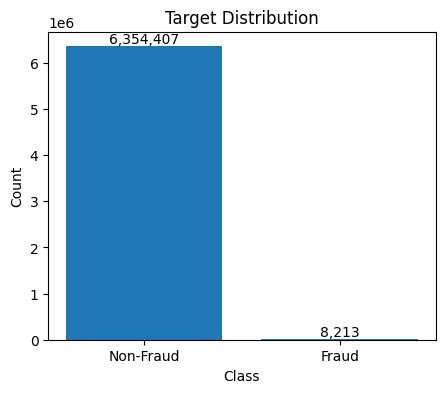

In [17]:
target_counts = df["isFraud"].value_counts().sort_index()

labels = ["Non-Fraud", "Fraud"]

plt.figure(figsize=(5,4))
plt.bar(labels, target_counts.values)
plt.title("Target Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

for i, v in enumerate(target_counts.values):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.show()

### Interpretation

The target variable is highly imbalanced, with fraudulent transactions representing only a very small fraction of the dataset. This class imbalance makes accuracy an unreliable performance metric, as a model can achieve high accuracy by predicting the majority class. Therefore, metrics such as Precision, Recall, F1-score, and ROC-AUC are more appropriate for evaluating model performance.

## Transaction Type Distribution

This visualization shows the frequency of each transaction type in the dataset. It helps identify the most common transaction categories and provides insight into the transaction distribution.

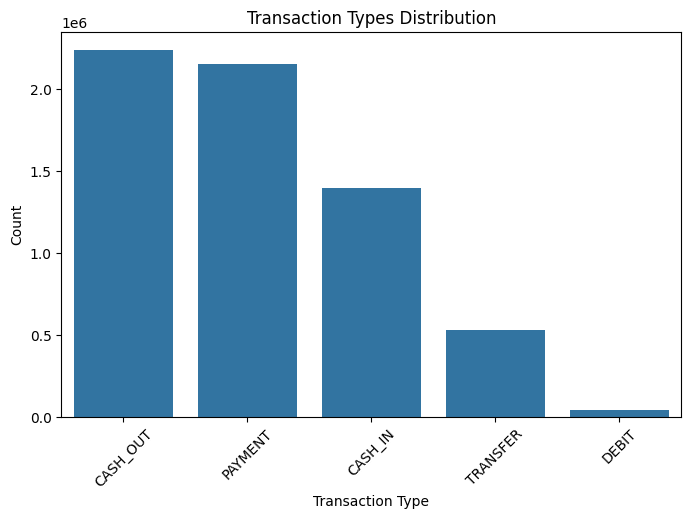

In [18]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x='type',
    order=df['type'].value_counts().index
)

plt.title('Transaction Types Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

### Interpretation

Most customers use only a few types of transactions regularly. By understanding which transaction types are common, we can better identify suspicious transactions that may be fraudulent.

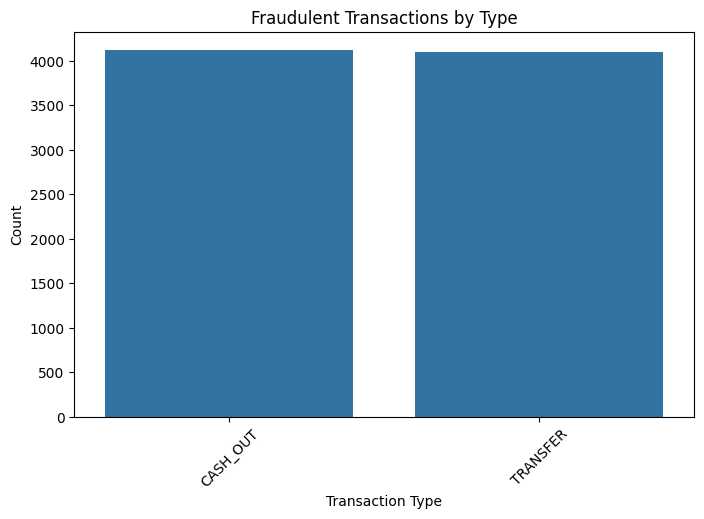

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_fraud,
    x='type',
    order=df_fraud['type'].value_counts().index
)

plt.title('Fraudulent Transactions by Type')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

## Fraud Rate by Transaction Type

This plot compares the percentage of fraudulent transactions across different transaction types. It helps determine whether fraud is concentrated in specific transaction categories.

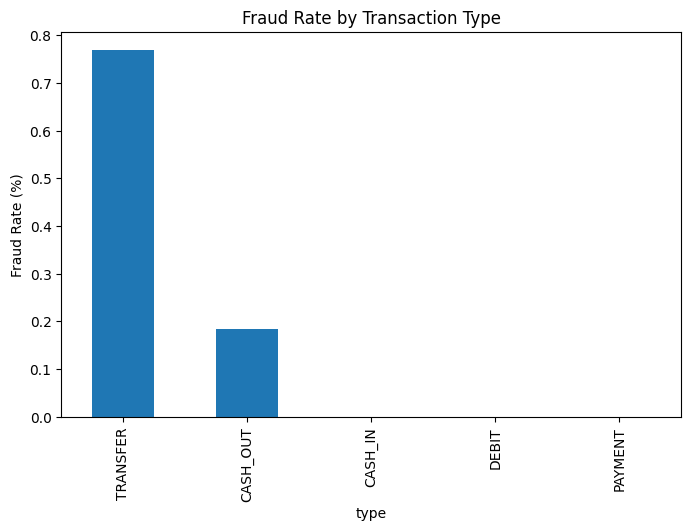

In [20]:
plt.figure(figsize=(8,5))
fraud_rate = (
    df.groupby("type")["isFraud"]
      .mean()
      .sort_values(ascending=False)*100
)

fraud_rate.plot(kind="bar")

plt.ylabel("Fraud Rate (%)")
plt.title("Fraud Rate by Transaction Type")
plt.show()

### Interpretation

Fraudulent transactions are concentrated primarily in CASH_OUT and TRANSFER transaction types, while other transaction types rarely contain fraudulent cases. This suggests that fraudsters exploit these transaction categories more frequently, making transaction type an important predictor for fraud detection.

## Distribution of Transaction Amount

The distribution of transaction amounts is highly right-skewed.Such skewness may affect model learning and motivates the use of log transformation for visualization and analysis.

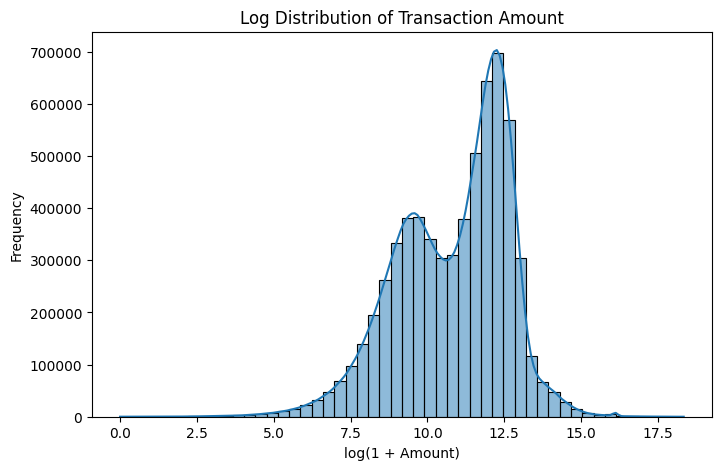

In [21]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df['amount']),
    bins=50,
    kde=True
)

plt.title('Log Distribution of Transaction Amount')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

After applying the logarithmic transformation, the transaction amounts form a much smoother and more balanced distribution. Most transactions are concentrated between log(1 + Amount) values of approximately 9 and 13, indicating that the majority of transactions fall within a moderate amount range. The transformation reduces the effect of extremely large transaction amounts, making the overall distribution easier to visualize and analyze. The presence of two peaks suggests that transactions tend to cluster around two common amount ranges rather than being evenly distributed.

## Distribution of Fraudulent Transaction Amounts

This visualization focuses only on fraudulent transactions to understand the range and distribution of fraud amounts.

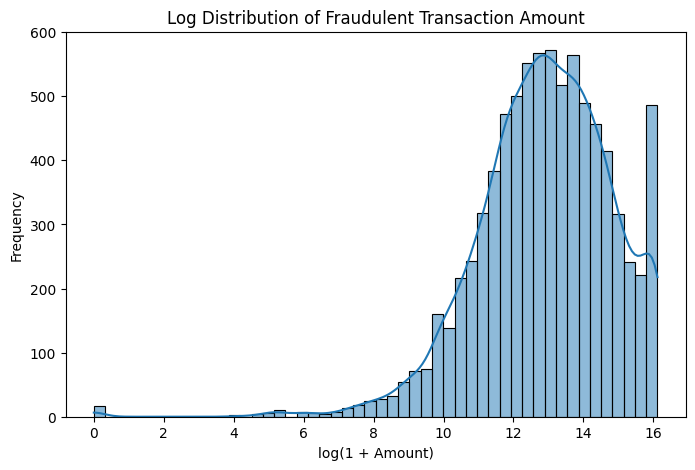

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(
    np.log1p(df_fraud['amount']),
    bins=50,
    kde=True
)

plt.title('Log Distribution of Fraudulent Transaction Amount')
plt.xlabel('log(1 + Amount)')
plt.ylabel('Frequency')

plt.show()

### Interpretation

Most fraudulent transactions involve relatively large amounts, while only a few involve small amounts. The graph shows that fraud is more common in higher-value transactions. Applying the log transformation makes the distribution easier to understand by reducing the impact of extremely large transaction amounts.

## Transactions by Day

This plot illustrates how transaction volume changes over different days in the simulation.

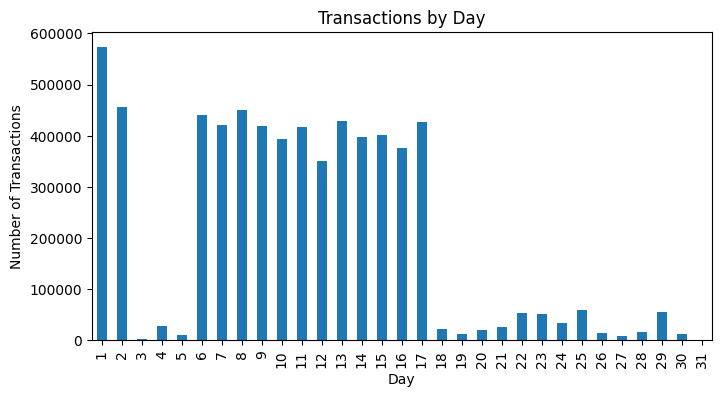

In [23]:
# Day
df["day"].value_counts().sort_index().plot(kind="bar", figsize=(8,4))
plt.xlabel("Day")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Day")
plt.show()



## Transactions by Hour

This visualization identifies the hours with the highest transaction activity.

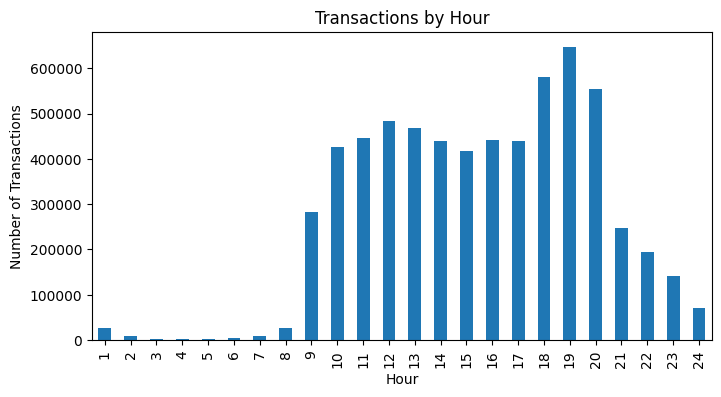

In [24]:
# Hour
df["hour"].value_counts().sort_index().plot(kind="bar", figsize=(8,4))
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.title("Transactions by Hour")
plt.show()

## Fraudulent Transactions by day

This plot examines whether fraudulent activities occur more frequently during specific days.

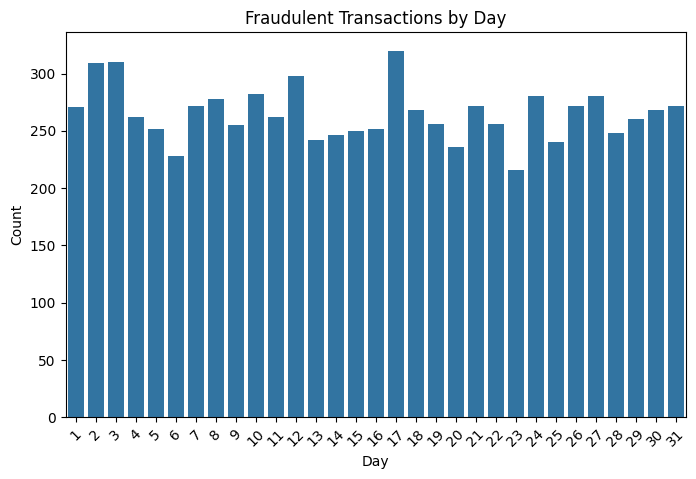

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_fraud,
    x='day',
    order=sorted(df_fraud['day'].unique())
)

plt.title('Fraudulent Transactions by Day')
plt.xlabel('Day')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [26]:
df_fraud['day'].value_counts(ascending=False)

day
17    320
3     310
2     309
12    298
10    282
24    280
27    280
8     278
21    272
26    272
31    272
7     272
1     271
30    268
18    268
11    262
4     262
29    260
19    256
22    256
9     255
5     252
16    252
15    250
28    248
14    246
13    242
25    240
20    236
6     228
23    216
Name: count, dtype: int64

## Fraudulent Transactions by Hour

This plot examines whether fraudulent activities occur more frequently during specific hours of the day.

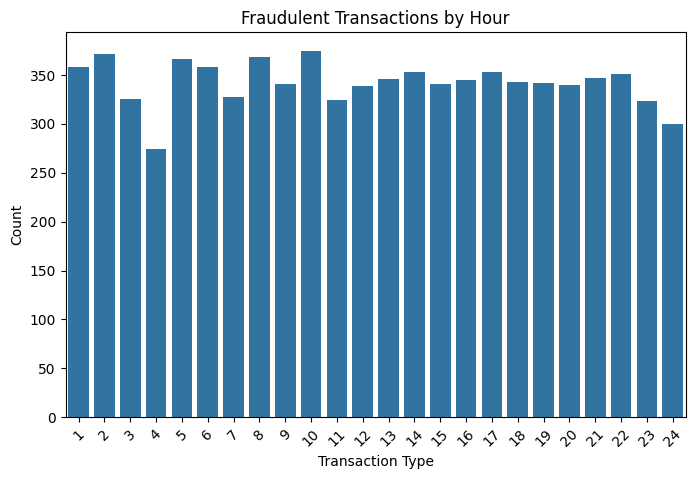

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df_fraud,
    x='hour',
    order=sorted(df_fraud['hour'].unique())
)

plt.title('Fraudulent Transactions by Hour')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

In [28]:
df_fraud['hour'].value_counts(ascending=False)

hour
10    375
2     372
8     368
5     366
6     358
1     358
14    353
17    353
22    351
21    347
13    346
16    345
18    343
19    342
15    341
9     341
20    340
12    339
7     328
3     326
11    324
23    323
24    300
4     274
Name: count, dtype: int64

## Transaction Amount by Fraud Status

This boxplot compares transaction amounts for legitimate and fraudulent transactions using a logarithmic scale.

findfont: Font family ['cmsy10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmr10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmtt10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmmi10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmb10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmss10'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmex10'] not found. Falling back to DejaVu Sans.


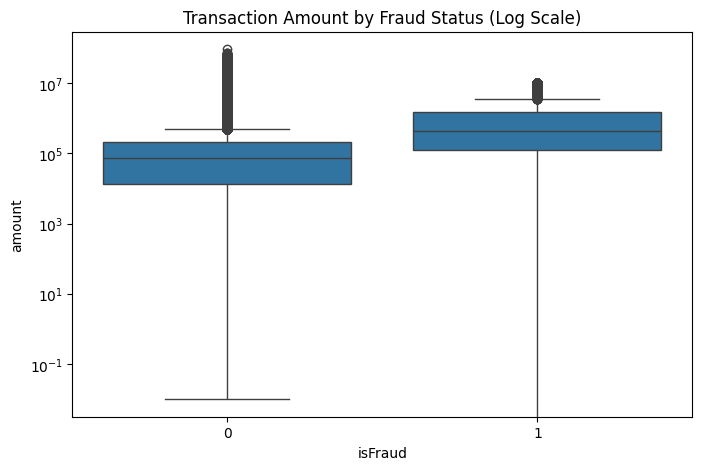

In [29]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='isFraud', y='amount')
plt.yscale('log')
plt.title('Transaction Amount by Fraud Status (Log Scale)')
plt.show()

### Interpretation:

The boxplot compares the distribution of transaction amounts for fraudulent and non-fraudulent transactions on a logarithmic scale.The presence of outliers in both groups indicates that very high-value transactions occur in both legitimate and fraudulent activities. However, the higher median and upper quartiles for fraudulent transactions suggest that fraud is more common among higher-value transactions.Therefore transaction amount is a useful predictor for fraud detection.

## Correlation Analysis

The correlation heatmap examines the linear relationships among numerical variables and their association with the target variable (isFraud).

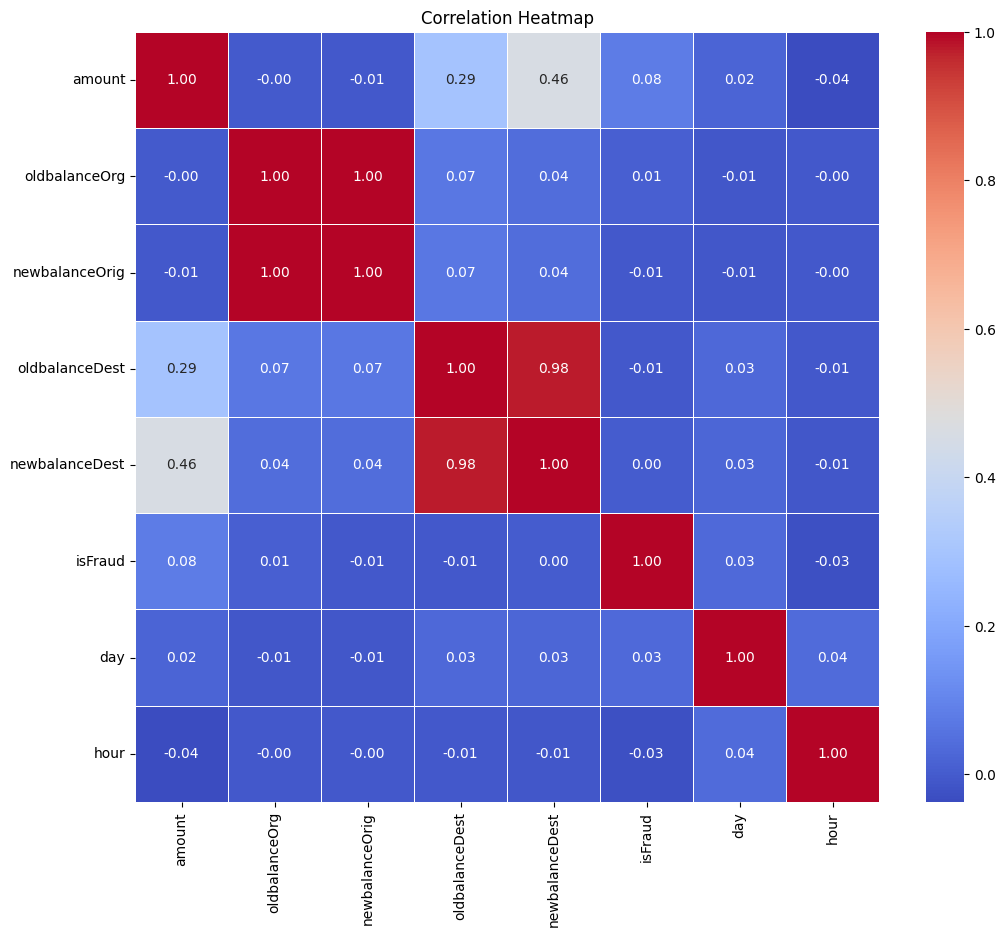

In [30]:
plt.figure(figsize=(12,10))
sns.heatmap(num_df.corr(),
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Heatmap")
plt.show()

### Interpretation 

Strong correlations are observed among the account balance features due to their mathematical dependence within each transaction. The target variable shows weak linear correlations with the predictor variables, suggesting that fraudulent behaviour is influenced by non-linear interactions among several features. This justifies the use of ensemble machine learning models such as Random Forest and XGBoost, which can effectively capture these complex relationships.

In [31]:
pd.crosstab(
    df["type"],
    df["isFraud"],
    normalize="index"
)*100

isFraud,0,1
type,,
CASH_IN,100.000000,0.000000
CASH_OUT,99.816045,0.183955
DEBIT,100.000000,0.000000
PAYMENT,100.000000,0.000000
TRANSFER,99.231201,0.768799


## oldbalanceOrg (Sender's Balance Before Transaction)

In [32]:
df.groupby('isFraud')['oldbalanceOrg'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,8.328287e+05,2.887144e+06,0.0,0.00,14069.00,106969.50,43818855.30
1,8213.0,1.649668e+06,3.547719e+06,0.0,125822.44,438983.45,1517771.48,59585040.37


### Interpretation

The sender's account balance before the transaction is generally higher for fraudulent transactions than for legitimate ones. The median balance before fraud (438,983.45) is much higher than for non-fraudulent transactions (14,069.00). This indicates that fraudulent transactions often originate from accounts with larger available balances. The large standard deviation in both groups suggests considerable variability in account balances.

## newbalanceOrig (Sender's Balance After Transaction)

In [33]:
df.groupby('isFraud')['newbalanceOrig'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,855970.228109,2.924987e+06,0.0,0.0,0.0,144730.74,43686616.33
1,8213.0,192392.631836,1.965666e+06,0.0,0.0,0.0,0.00,49585040.37


### Interpretation

After fraudulent transactions, the sender's remaining balance is typically zero, as reflected by the median and upper quartile values. In contrast, legitimate transactions usually leave a positive balance in the sender's account. This pattern suggests that fraudulent transactions often drain most or all of the available funds from the sender's account, making this feature a strong indicator of fraud.

## oldbalanceDest (Receiver's Balance Before Transaction)

In [34]:
df.groupby('isFraud')['oldbalanceDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.101421e+06,3.399202e+06,0.0,0.0,133311.8,944144.58,3.560159e+08
1,8213.0,5.442496e+05,3.336421e+06,0.0,0.0,0.0,147828.66,2.362305e+08


### Interpretation

Before the transaction, recipient accounts involved in legitimate transactions generally have higher balances than those involved in fraudulent transactions. The median balance for fraudulent transactions is zero, indicating that many fraudulent transfers are made to destination accounts with little or no prior balance. This behaviour may reflect the use of newly created or inactive accounts by fraudsters.

## newbalanceDest (Receiver's Balance After Transaction)

In [35]:
df.groupby('isFraud')['newbalanceDest'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,6354407.0,1.224926e+06,3.673816e+06,0.0,0.0,214881.70,1111975.345,3.561793e+08
1,8213.0,1.279708e+06,3.908817e+06,0.0,0.0,4676.42,1058725.220,2.367265e+08


### Interpretation

After the transaction, recipient accounts typically have much higher balances than fraudulent recipient accounts. The median balance for fraudulent transactions remains relatively low, suggesting that the transferred funds are often quickly withdrawn or moved to other accounts. This difference indicates that the destination account balance can provide useful information for distinguishing fraudulent transactions.

# Statistical Analysis

Statistical hypothesis tests were performed to validate relationships observed during exploratory data analysis.
The following tests were conducted:

- Chi-Square Test
- Cramer's V
- Mann-Whitney U Test
- Serial Correlation

## Chi-Square Test

The Chi-Square test evaluates whether transaction type and fraud occurrence are statistically associated.

Null Hypothesis (H₀):
Transaction type and fraud occurrence are independent.

Alternative Hypothesis (H₁):
Transaction type and fraud occurrence are associated.

In [36]:
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df["type"], df["isFraud"])

chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square Statistic :", chi2)
print("Degrees of Freedom   :", dof)
print("P-value              :", p)

Chi-square Statistic : 22082.53571319108
Degrees of Freedom   : 4
P-value              : 0.0


In [37]:
if p < 0.05:
    print("Significant association between Transaction Type and Fraud.")
else:
    print("No significant association.")

Significant association between Transaction Type and Fraud.


### Interpretation

Since the p-value is less than 0.05, the null hypothesis is rejected. This indicates a statistically significant association between transaction type and fraud occurrence.

## Cramer's V

In [18]:
import numpy as np

n = contingency.values.sum()

phi2 = chi2 / n

r, k = contingency.shape

cramers_v = np.sqrt(phi2 / (min(r-1, k-1)))

print("Cramer's V =", round(cramers_v,4))

NameError: name 'contingency' is not defined

## Interpretation

The Cramér's V value of 0.05 indicates a very weak association between transaction type and fraud status. This suggests that transaction type alone is not a strong predictor of whether a transaction is fraudulent. However, transaction type may still contribute to fraud detection when combined with other features such as transaction amount and account balances in a machine learning model.
Although fraudulent transactions are concentrated in specific transaction types such as TRANSFER and CASH_OUT, the overall Cramér's V value is low because fraudulent transactions represent only a very small proportion of the dataset. This severe class imbalance reduces the measured strength of association between transaction type and fraud status.

## Mann-Whitney U Test

Null Hypothesis (H₀): The distribution of transaction amounts is the same for fraudulent and non-fraudulent transactions.

Alternative Hypothesis (H₁): The distributions are different.

Since the histogram and boxplot showed that the transaction amount was highly skewed with several outliers, the assumptions of the independent t-test were not satisfied. Therefore, the Mann–Whitney U test was selected to determine whether there was a significant difference in transaction amounts between fraudulent and non-fraudulent transactions.

In [39]:
from scipy.stats import mannwhitneyu

fraud = df[df["isFraud"] == 1]["amount"]

non_fraud = df[df["isFraud"] == 0]["amount"]

stat, p = mannwhitneyu(
    fraud,
    non_fraud,
    alternative="two-sided"
)

print("Statistic :", stat)
print("P-value   :", p)

Statistic : 41224999611.0
P-value   : 0.0


In [40]:
if p < 0.05:
    print("Transaction amounts differ significantly.")
else:
    print("No significant difference.")

Transaction amounts differ significantly.


## Interpretation

The Mann–Whitney U test was conducted to determine whether the distribution of transaction amounts differs significantly between fraudulent and non-fraudulent transactions. The test produced a p-value of 0.0 (p < 0.001), indicating a statistically significant difference between the two groups. Therefore, we reject the null hypothesis and conclude that fraudulent and legitimate transactions have significantly different transaction amount distributions

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
    stratify=y,random_state=42)
print("Training Shape :", X_train.shape)
print("Testing Shape  :", X_test.shape)

Training Shape : (5090096, 8)
Testing Shape  : (1272524, 8)


In [23]:
numeric_features = ["amount","oldbalanceOrg","newbalanceOrig",
    "oldbalanceDest", "newbalanceDest","day","hour"]
categorical_features = ["type"]

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [25]:
preprocessor_lr = ColumnTransformer(
    transformers=[
        ("num",StandardScaler(),numeric_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
    ]
)

In [26]:
preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)],
    remainder="passthrough"
)

In [27]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [28]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

## Logistic Regression

Logistic Regression is used as a baseline linear classification model. Due to class imbalance, SMOTE is applied to the training data.

In [29]:
from sklearn.linear_model import LogisticRegression
lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor_lr),
        ("smote", SMOTE(random_state=42)),
        ("model",LogisticRegression(random_state=42,max_iter=1000))
          ]
)

In [30]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['amount', 'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest', 'day',
                                                   'hour']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('smote', SMOTE(random_state=42)),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])

In [31]:
y_pred_lr = lr_pipeline.predict(X_test)
y_prob_lr = lr_pipeline.predict_proba(X_test)[:,1]

## Random Forest

Random Forest is an ensemble learning algorithm capable of capturing complex non-linear relationships while being robust to overfitting.

In [32]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor_tree),
        ("model",RandomForestClassifier(n_estimators=50,
                max_depth=15,class_weight="balanced",
                random_state=42,n_jobs=-1))
         ]
)

In [33]:
rf_pipeline.fit(X_train, y_train)

C:\Users\MY PC\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', max_depth=15,
                                        n_estimators=50, n_jobs=-1,
                                        random_state=42))])

In [34]:
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:,1]

## XGBoost

XGBoost is a gradient boosting algorithm designed for high predictive performance and efficient handling of imbalanced datasets.

In [35]:
!pip install xgboost

In [36]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(scale_pos_weight)

773.7482496194825


In [37]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor",preprocessor_tree),
        ("model",XGBClassifier(random_state=42,
                eval_metric="logloss",tree_method="hist",
                scale_pos_weight=scale_pos_weight,
                learning_rate=0.1,n_estimators=100,
                max_depth=6,n_jobs=-1))
          ]
)

In [38]:
xgb_pipeline.fit(X_train, y_train)

C:\Users\MY PC\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['type'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_m...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [39]:
y_pred_xgb = xgb_pipeline.predict(X_test)

y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:,1]

# Model Evaluation

Model performance is evaluated using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC

In [40]:
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Random Forest",
              "XGBoost"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb)
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb)
    ],

    "ROC AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_xgb)
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9540,0.0262,0.9580,0.0510,0.9917
1,Random Forest,0.9958,0.2301,0.9647,0.3716,0.9989
2,XGBoost,0.9939,0.1747,0.9957,0.2973,0.9998


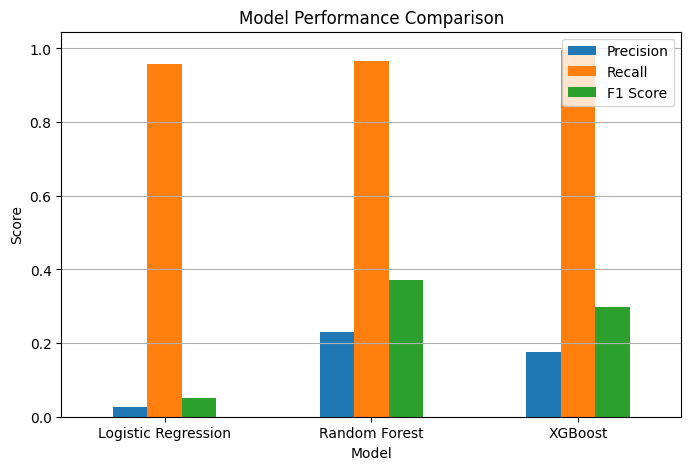

In [41]:
import matplotlib.pyplot as plt

plot_df = results.set_index("Model")

plot_df[["Precision", "Recall", "F1 Score"]].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.show()

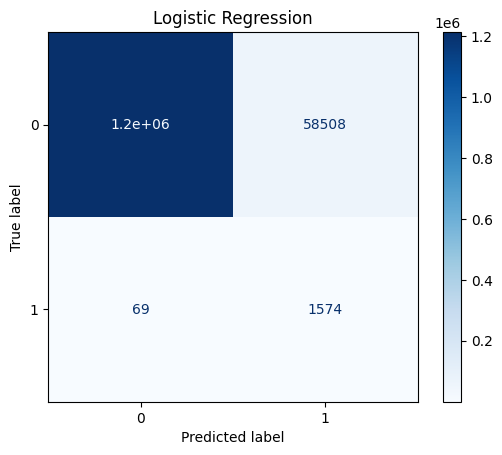

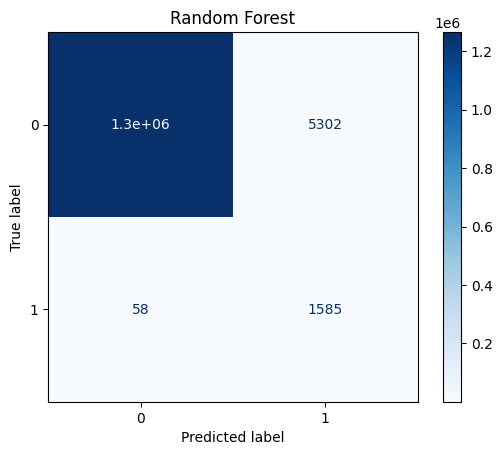

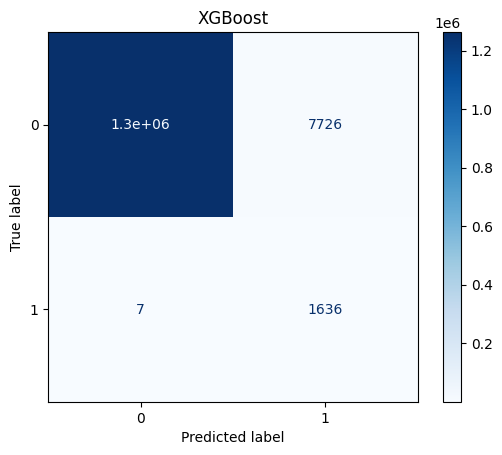

In [42]:
from sklearn.metrics import ConfusionMatrixDisplay

models = [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest", y_pred_rf),
    ("XGBoost", y_pred_xgb)
]

for name, pred in models:
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        cmap="Blues"
    )
    plt.title(name)
    plt.show()

<Figure size 800x600 with 0 Axes>

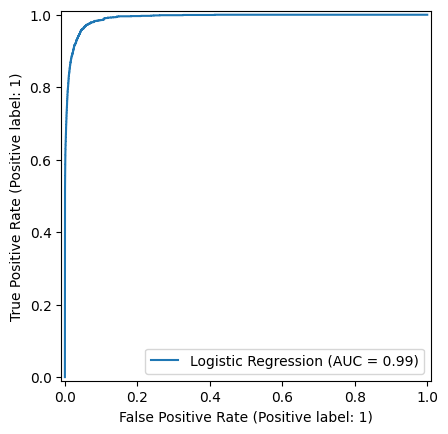

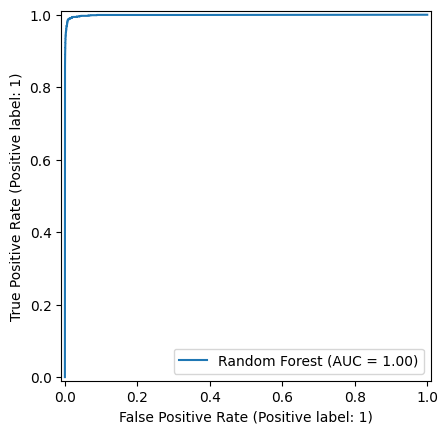

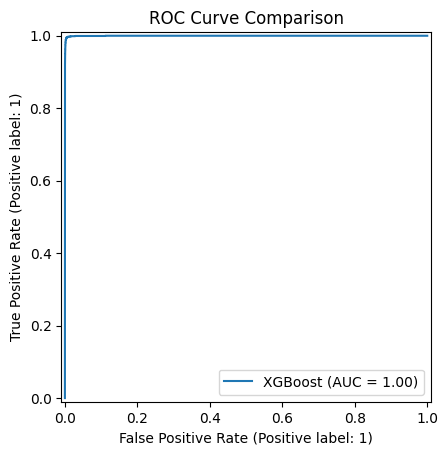

In [43]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_xgb,
    name="XGBoost"
)

plt.title("ROC Curve Comparison")
plt.show()

In [65]:
from sklearn.model_selection import train_test_split
X_train_tune, _, y_train_tune, _ = train_test_split(
    X_train,y_train,train_size=500000,
    stratify=y_train,random_state=42)

print(X_train_tune.shape)
print(y_train_tune.value_counts())

(500000, 8)
isFraud
0    499355
1       645
Name: count, dtype: int64


# Hyperparameter Tuning

RandomizedSearchCV is used to optimize model performance by searching across different combinations of hyperparameters using cross-validation.

In [69]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    "model__n_estimators": [100, 200,300],
    "model__max_depth": [10, 20,None],
    "model__min_samples_split": [2, 5,10],
    "model__min_samples_leaf": [1,2,4],
    "model__max_features": ["sqrt","log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid_rf,
    n_iter=5,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

rf_search.fit(X_train_tune, y_train_tune)

print("Best Parameters:")
print(rf_search.best_params_)

print("\nBest CV F1:")
print(rf_search.best_score_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}

Best CV F1:
0.871524640898111


In [70]:
best_rf = rf_search.best_estimator_

y_pred_best_rf = best_rf.predict(X_test)
y_prob_best_rf = best_rf.predict_proba(X_test)[:,1]

In [71]:
print("Accuracy :", accuracy_score(y_test, y_pred_best_rf
print("Precision:", precision_score(y_test, y_pred_best_rf))
print("Recall   :", recall_score(y_test, y_pred_best_rf))
print("F1 Score :", f1_score(y_test, y_pred_best_rf))print("ROC AUC  :", roc_auc_scre(y_test, y_prob_best_rf))

Accuracy : 0.9996903791205509
Precision: 0.9602063375092115
Recall   : 0.7930614729153986
F1 Score : 0.8686666666666667
ROC AUC  : 0.9984727269119918


In [72]:
param_grid_xgb = {
    "model__n_estimators":[100,200,300],
    "model__max_depth":[4,6,8],
    "model__learning_rate":[0.01,0.05,0.1],
    "model__subsample":[0.8,1.0],
    "model__colsample_bytree":[0.8,1.0],
    "model__min_child_weight":[1,3,5]
}

In [73]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_grid_xgb,
    n_iter=10,
    scoring="f1",
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

xgb_search.fit(X_train_tune, y_train_tune)

print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV F1:")
print(xgb_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\MY PC\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

Best CV F1:
0.8575458937816575


In [74]:
best_xgb = xgb_search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:,1]

In [75]:
("Accuracy :", accuracy_score(y_test, y_pred_best_xgb))
print("Precision:", precision_score(y_test, y_pred_best_xgb
print("Recall   :", recall_score(y_test, y_pred_best_xgb))print("F1 Score :", f1_score(y_test, y_pred_best_xgb))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_best_xgb))

Accuracy : 0.9995622872338753
Precision: 0.7983516483516484
Recall   : 0.884357881923311
F1 Score : 0.8391568004620271
ROC AUC  : 0.9990158580322954


In [76]:
results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],

    "Accuracy":[
        accuracy_score(y_test,y_pred_lr),
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_xgb),
        accuracy_score(y_test,y_pred_best_rf),
        accuracy_score(y_test,y_pred_best_xgb)
    ],

    "Precision":[
        precision_score(y_test,y_pred_lr),
        precision_score(y_test,y_pred_rf),
        precision_score(y_test,y_pred_xgb),
        precision_score(y_test,y_pred_best_rf),
        precision_score(y_test,y_pred_best_xgb)
    ],

    "Recall":[
        recall_score(y_test,y_pred_lr),
        recall_score(y_test,y_pred_rf),
        recall_score(y_test,y_pred_xgb),
        recall_score(y_test,y_pred_best_rf),
        recall_score(y_test,y_pred_best_xgb)
    ],

    "F1 Score":[
        f1_score(y_test,y_pred_lr),
        f1_score(y_test,y_pred_rf),
        f1_score(y_test,y_pred_xgb),
        f1_score(y_test,y_pred_best_rf),
        f1_score(y_test,y_pred_best_xgb)
    ],

    "ROC AUC":[
        roc_auc_score(y_test,y_prob_lr),
        roc_auc_score(y_test,y_prob_rf),
        roc_auc_score(y_test,y_prob_xgb),
        roc_auc_score(y_test,y_prob_best_rf),
        roc_auc_score(y_test,y_prob_best_xgb)
    ]

})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.9540,0.0262,0.9580,0.0510,0.9917
1,Random Forest,0.9958,0.2301,0.9647,0.3716,0.9989
2,XGBoost,0.9939,0.1747,0.9957,0.2973,0.9998
3,Tuned Random Forest,0.9997,0.9602,0.7931,0.8687,0.9985
4,Tuned XGBoost,0.9996,0.7984,0.8844,0.8392,0.9990


## Model Selection

Among all evaluated models, the tuned Random Forest achieved the best overall balance between Precision, Recall, F1-score, and ROC-AUC. Therefore, it was selected as the final model for deployment.

In [79]:
from sklearn.metrics import classimator_.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[1270827      54]
 [    340    1303]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.96      0.79      0.87      1643

    accuracy                           1.00   1272524
   macro avg       0.98      0.90      0.93   1272524
weighted avg       1.00      1.00      1.00   1272524



In [77]:
print(rf_search.best_params_)
print(xgb_search.best_params_)

{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': None}
{'model__subsample': 1.0, 'model__n_estimators': 300, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}


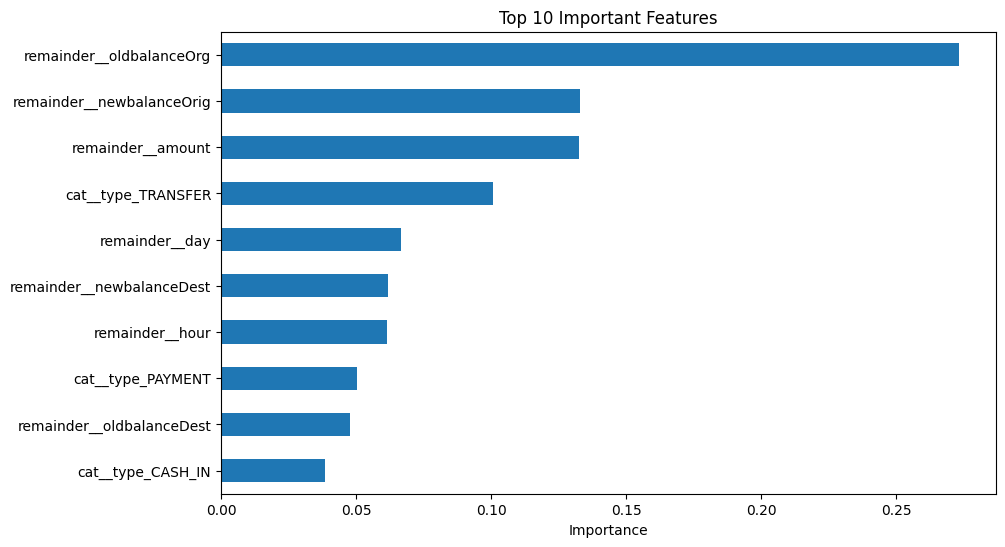

In [78]:
feature_names = best_rf.named_steps["prep
importance = pd.Series(
    best_rf.named_steps["model"].feature_importances_,
    index=feature_names
).sort_values(ascending=False)

plt.figure(figsize=(10,6))

importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Important Features")
plt.xlabel("Importance")

plt.show()

### Interpretation

- Balance-related variables contribute most to the model's predictions.
- Transaction type and transaction amount are also influential predictors.
- These findings are consistent with patterns observed during exploratory data analysis.

In [ ]:
import joblib

joblib.dump(best_rf, "fraud_detection_pipeline.pkl")

# Deployment

The final trained Random Forest pipeline was serialized using Joblib and deployed as an interactive web application using Streamlit.

The application allows users to enter transaction details and obtain fraud predictions in real time.

In [19]:
import os
print(os.getcwd())

C:\Users\MY PC\project
